# Markov Chains

### Cloudy or sunny days

We call a cloudy day 0 and a sunny day 1. 

![image.png](https://miro.medium.com/max/416/1*frksGjINf5oTjx7WL81U3w.png)

The stationary sunny probability is $p_* = \frac{0.5}{0.5 + 0.1} \approx 0.833$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
today = 0
N = 10000
p_clear = []
current_p_clear = 0

In [4]:
for i in range(N):
    if today == 0:
        tomorrow = np.random.choice([0, 1], p=[0.5, 0.5])
    elif today == 1:
        tomorrow = np.random.choice([0, 1], p=[0.1, 0.9])
    else:
        raise ValueError("today should be 0 or 1")

    today = tomorrow

    if today == 1:
        current_p_clear += 1
    p_clear.append(current_p_clear / (i + 1))

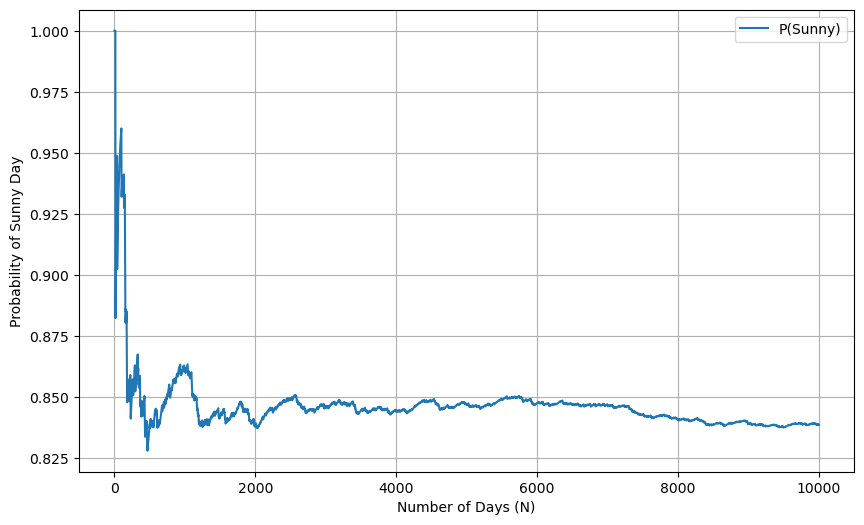

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(range(N), p_clear, label="P(Sunny)")
plt.xlabel("Number of Days (N)")
plt.ylabel("Probability of Sunny Day")
plt.legend()
plt.grid()
plt.show()

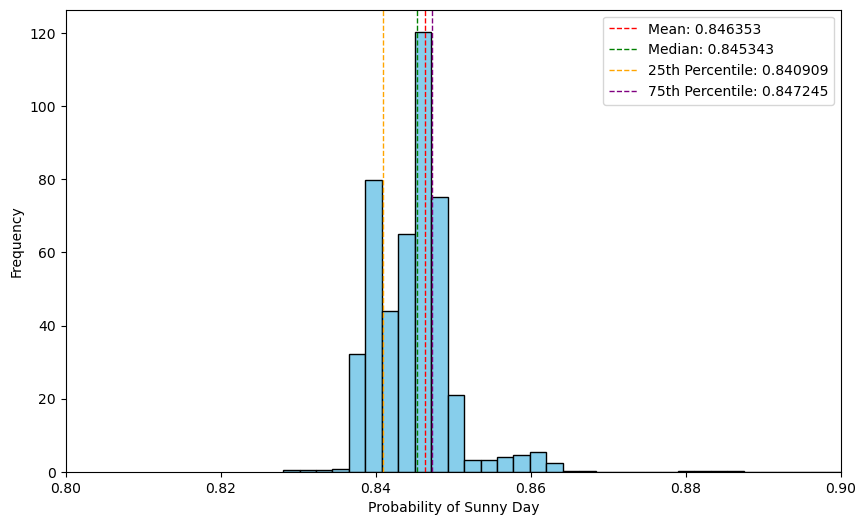

In [6]:
mean = np.mean(p_clear)
median = np.median(p_clear)
percentile_25 = np.percentile(p_clear, 25)
percentile_75 = np.percentile(p_clear, 75)

plt.figure(figsize=(10, 6))
plt.hist(p_clear, bins="scott", density=True, color='skyblue', edgecolor='black')
plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.6f}')
plt.axvline(median, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median:.6f}')
plt.axvline(percentile_25, color='orange', linestyle='dashed', linewidth=1, label=f'25th Percentile: {percentile_25:.6f}')
plt.axvline(percentile_75, color='purple', linestyle='dashed', linewidth=1, label=f'75th Percentile: {percentile_75:.6f}')
plt.xlabel("Probability of Sunny Day")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0.8, 0.9)
plt.show()

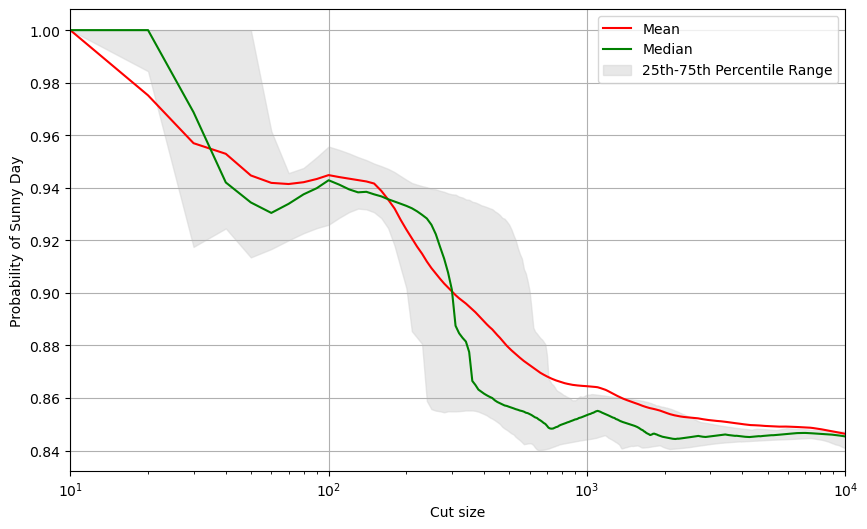

In [19]:
cuts = np.arange(10, 10001, 10)
medians, means, percentile_25s, percentile_75s = [], [], [], []

for cut in cuts:
    if cut == 0:
        medians.append(np.nan)
        means.append(np.nan)
        percentile_25s.append(np.nan)
        percentile_75s.append(np.nan)
        continue

    window = p_clear[:cut]
    medians.append(np.median(window))
    means.append(np.mean(window))
    percentile_25s.append(np.percentile(window, 25))
    percentile_75s.append(np.percentile(window, 75))

plt.figure(figsize=(10, 6))
plt.plot(cuts, means, label="Mean", color='red')
plt.plot(cuts, medians, label="Median", color='green')
plt.fill_between(cuts, percentile_25s, percentile_75s, color='lightgray', alpha=0.5, label="25th-75th Percentile Range")
plt.xlabel("Cut size")
plt.ylabel("Probability of Sunny Day")
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlim(10, 10000)
plt.show()

In [8]:
p_clear_cutted = p_clear[:4000]

In [9]:
import numpy as np
from sklearn.neighbors import KernelDensity

def estimate_density(data, bandwidth, kernel):
    kde = KernelDensity(kernel=kernel, bandwidth=bandwidth)
    kde.fit(data[:, None])
    return kde

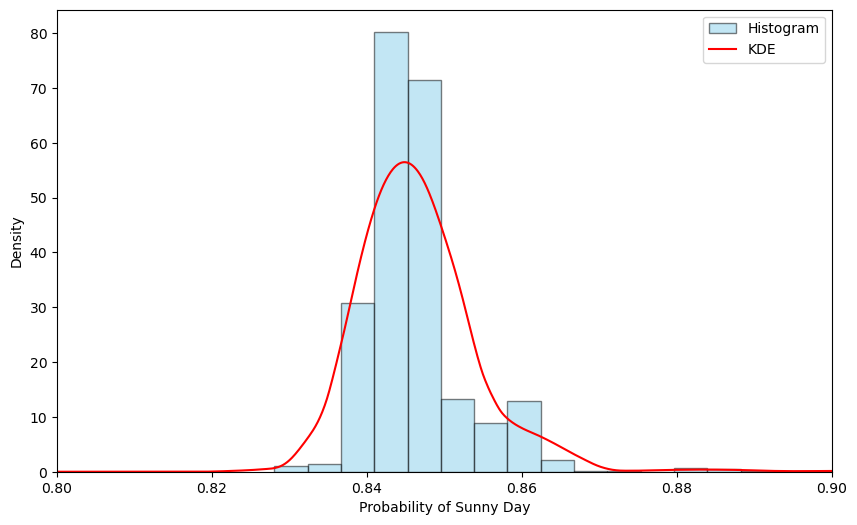

In [10]:
estimated_kde = estimate_density(np.array(p_clear_cutted), bandwidth=0.01, kernel='epanechnikov')

grid = np.linspace(0.8, 0.9, 1000)[:, None]
log_density = estimated_kde.score_samples(grid)

plt.figure(figsize=(10, 6))
plt.hist(p_clear_cutted, bins="scott", density=True, color='skyblue', edgecolor='black', alpha=0.5, label="Histogram")
plt.plot(grid[:, 0], np.exp(log_density), color='red', label="KDE")
plt.xlabel("Probability of Sunny Day")
plt.ylabel("Density")
plt.legend()
plt.xlim(0.8, 0.9)
plt.show()

### Finance

Redo in a new case from finance. The Markovian proces to simulate is rappresented graphically:

![](https://upload.wikimedia.org/wikipedia/commons/9/95/Finance_Markov_chain_example_state_space.svg)

Bull = 0, Bear = 1, Stagn= 2.


In [11]:
attual = 0
p_stg = []
p_bull = []
p_bear = []
current_p_stg = 0
current_p_bull = 0
current_p_bear = 0

In [12]:
for i in range(N):
    if attual == 0:
        future = np.random.choice([0, 1, 2], p=[0.9, 0.075, 0.025])
    elif attual == 1:
        future = np.random.choice([0, 1, 2], p=[0.15, 0.8, 0.05])
    elif attual == 2:
        future = np.random.choice([0, 1, 2], p=[0.25, 0.25, 0.5])
    else:
        raise ValueError("attual should be 0, 1, or 2")

    attual = future

    if attual == 0:
        current_p_bull += 1
    elif attual == 1:
        current_p_bear += 1
    elif attual == 2:
        current_p_stg += 1
    else:
        raise ValueError("attual should be 0, 1, or 2")
    
    p_stg.append(current_p_stg / (i + 1))
    p_bull.append(current_p_bull / (i + 1))
    p_bear.append(current_p_bear / (i + 1))

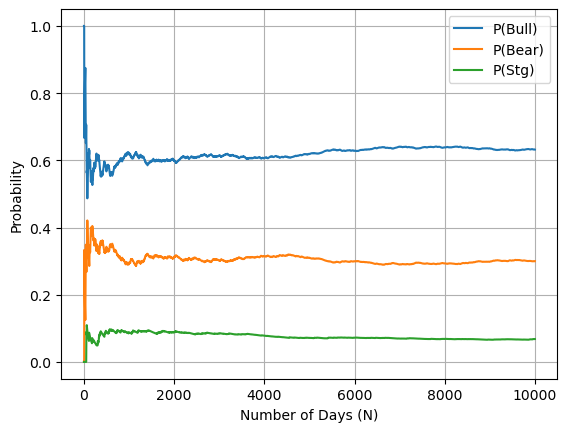

In [13]:
plt.plot(range(N), p_bull, label="P(Bull)")
plt.plot(range(N), p_bear, label="P(Bear)")
plt.plot(range(N), p_stg, label="P(Stg)")
plt.xlabel("Number of Days (N)")
plt.ylabel("Probability")
plt.legend()
plt.grid()
plt.show()

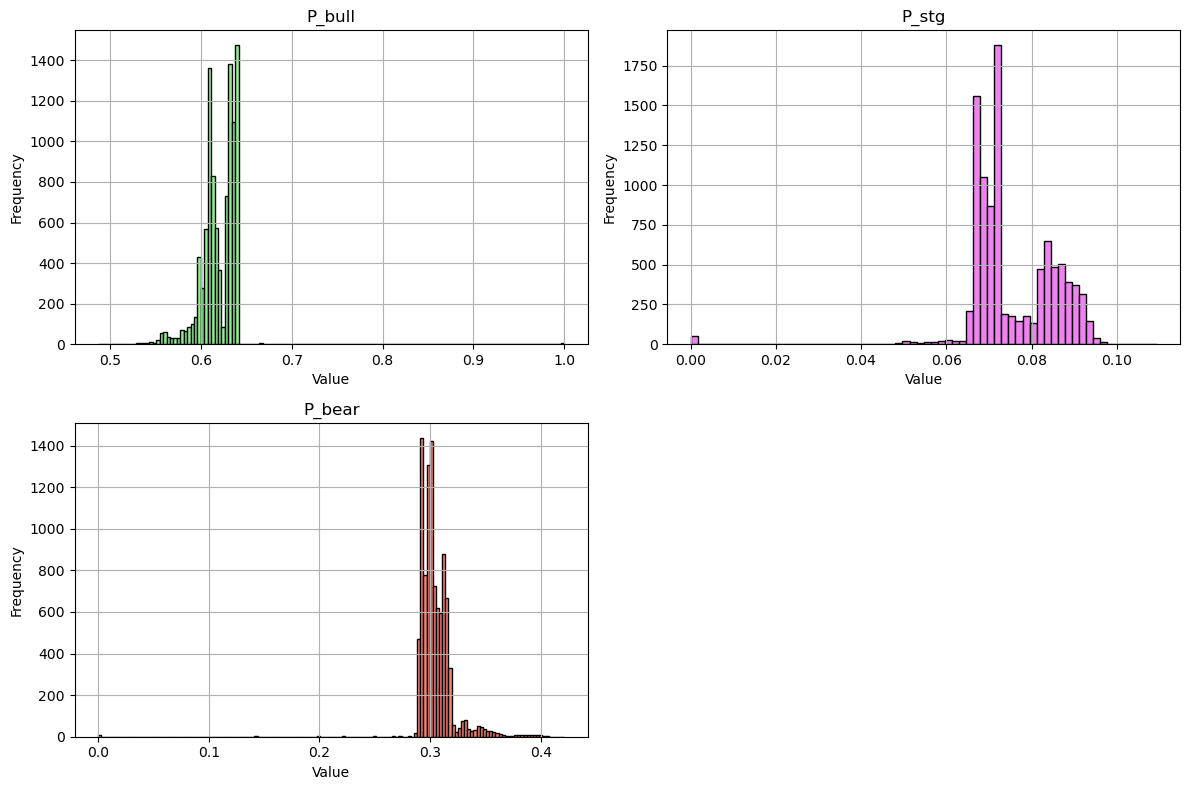

p_bull: Median = 0.620747, 25th Percentile = 0.608910, 75th Percentile = 0.634922
p_bear: Median = 0.301321, 25th Percentile = 0.295788, 75th Percentile = 0.311094
p_stg: Median = 0.071931, 25th Percentile = 0.068257, 75th Percentile = 0.083957


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(p_bull, bins="scott", color="lightgreen", edgecolor="black")
axes[0, 0].set_title("P_bull")
axes[0, 0].set_xlabel("Value")
axes[0, 0].set_ylabel("Frequency")

axes[1, 0].hist(p_bear, bins="scott", color="salmon", edgecolor="black")
axes[1, 0].set_title("P_bear")
axes[1, 0].set_xlabel("Value")
axes[1, 0].set_ylabel("Frequency")

axes[0, 1].hist(p_stg, bins="scott", color="violet", edgecolor="black")
axes[0, 1].set_title("P_stg")
axes[0, 1].set_xlabel("Value")
axes[0, 1].set_ylabel("Frequency")

axes[1, 1].axis("off")

for ax in axes.ravel():
    ax.grid(True)

plt.tight_layout()
plt.show()

median_bull, perc25_bull, perc75_bull = np.median(p_bull), np.percentile(p_bull, 25), np.percentile(p_bull, 75)
median_bear, perc25_bear, perc75_bear = np.median(p_bear), np.percentile(p_bear, 25), np.percentile(p_bear, 75)
median_stg, perc25_stg, perc75_stg = np.median(p_stg), np.percentile(p_stg, 25), np.percentile(p_stg, 75)

print(f"p_bull: Median = {median_bull:.6f}, 25th Percentile = {perc25_bull:.6f}, 75th Percentile = {perc75_bull:.6f}")
print(f"p_bear: Median = {median_bear:.6f}, 25th Percentile = {perc25_bear:.6f}, 75th Percentile = {perc75_bear:.6f}")
print(f"p_stg: Median = {median_stg:.6f}, 25th Percentile = {perc25_stg:.6f}, 75th Percentile = {perc75_stg:.6f}")